
===== 簇 0 =====
random forest
radiomics
survival analysis
encoding
logistic regression
modeling
supervised learning
covid-19
causal inference
unsupervised learning
breast cancer
prognosis
artificial neural networks
linear regression
clustering
decision tree
data science
mortality
prediction
risk assessment
machine learning
regression
systematic review
big data
svm
classification
prediction model
xgboost
artificial intelligence
image processing
cancer
natural language processing
deep learning
spatial statistics

===== 簇 1 =====
principal component analysis
sensors
cybersecurity
deep neural network
statistics
support vector machine
extreme learning machine
artificial neural network
monitoring

===== 簇 2 =====
uncertartificial intelligencenty quantification
lstm
arima
remote sensing
ensemble learning
time series analysis
forecasting
bayesian statistics
neural network
internet of things
time series
neural networks
predictive models
uncertartificial intelligencenty
data models

===== 簇 3 =

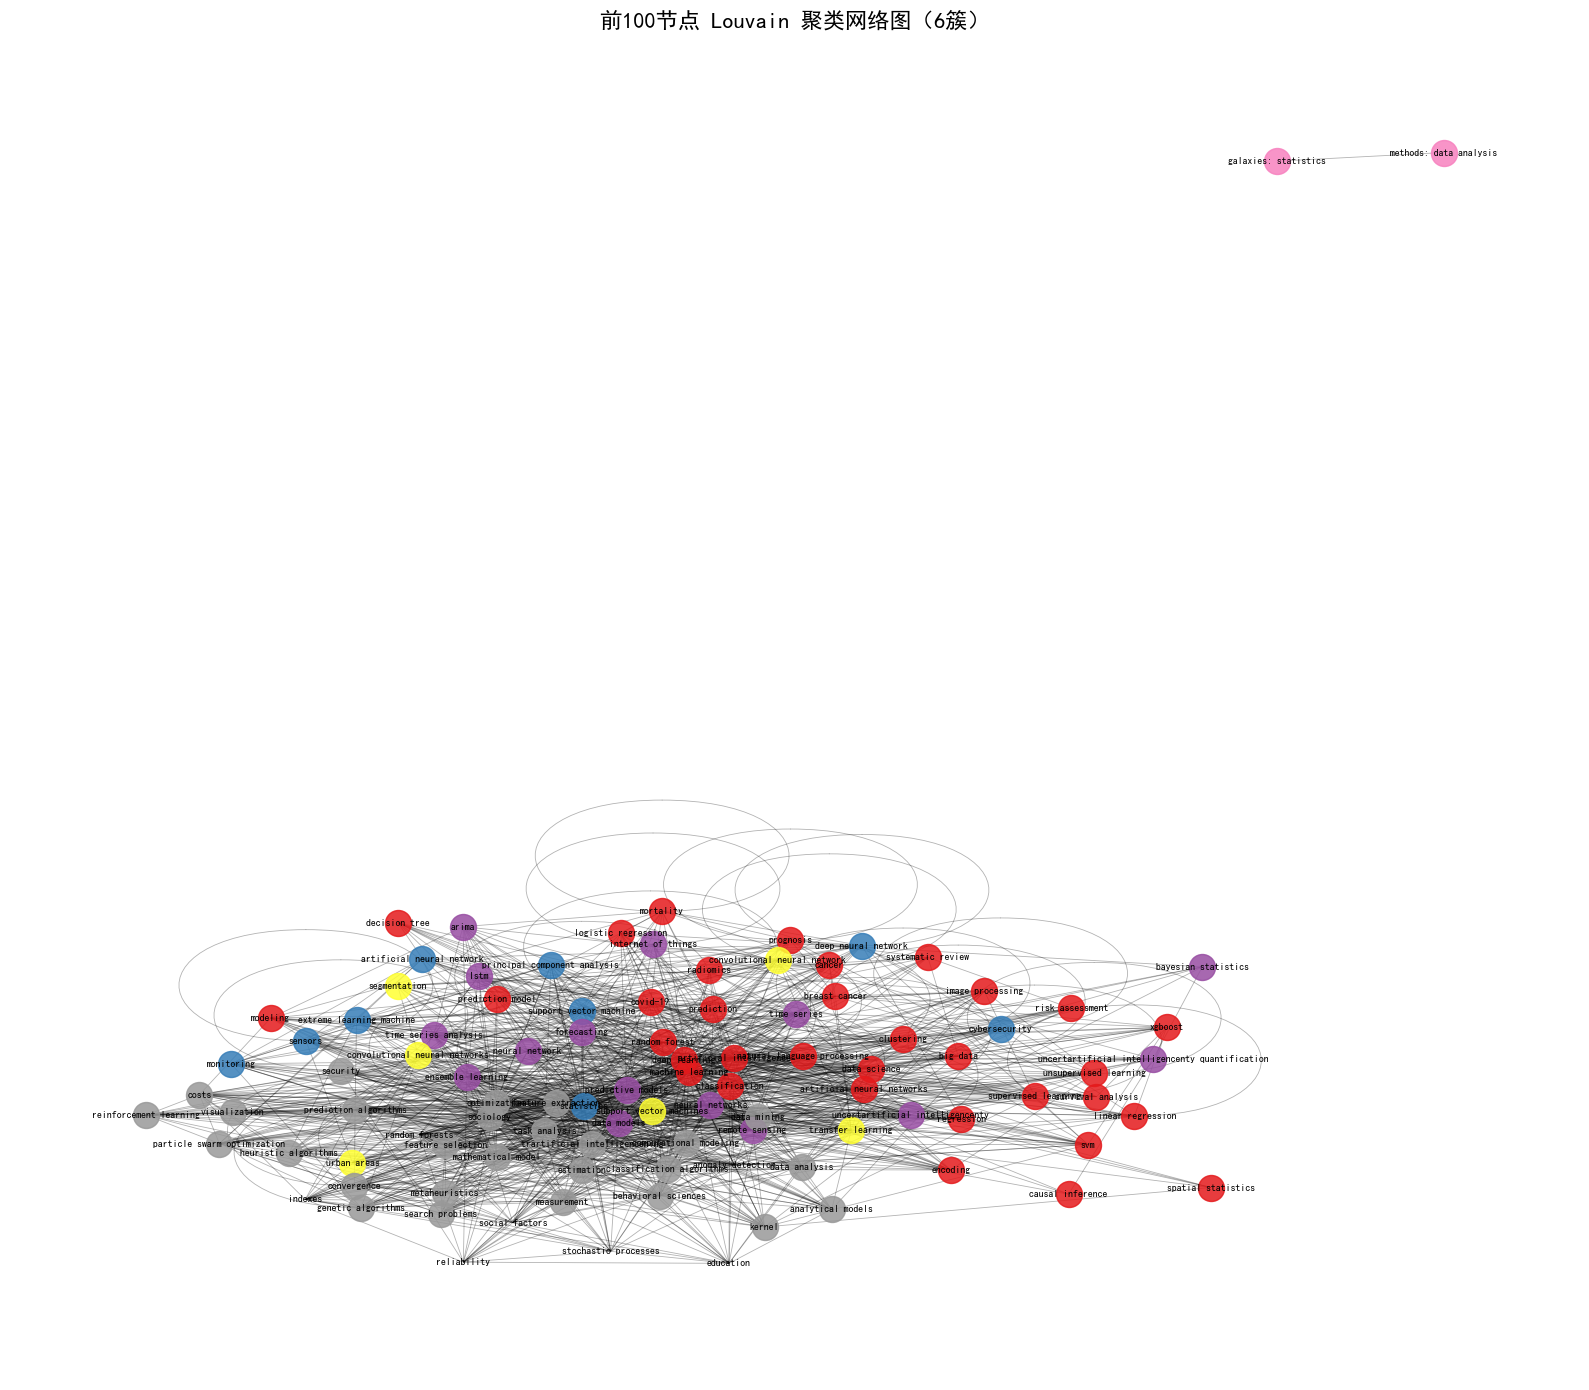

In [13]:
import pandas as pd
import networkx as nx
import community as community_louvain
from collections import defaultdict
import matplotlib.pyplot as plt

# 1. 加载数据并构建图
df = pd.read_csv('statistics_edges.csv', delimiter=',', skiprows=1, names=['Source', 'Target', 'Weight'])
G = nx.Graph()
for index, row in df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

# ===================== 从 custom_sorted1.csv 取前100个节点 =====================
custom_sorted = pd.read_csv('custom_sorted1.csv')
top100_nodes = custom_sorted.iloc[:, 0].head(100).tolist()

# 3. 只保留前100个节点的子图
subG = G.subgraph(top100_nodes).copy()

# 4. Louvain 聚类
partition = community_louvain.best_partition(
    subG, 
    weight='Weight',
    partition=None,
    resolution=0.92
)

# 5. 按簇分组输出结果
clusters = defaultdict(list)
for node, cid in partition.items():
    clusters[cid].append(node)

for cid, nodes in sorted(clusters.items()):
    print(f"\n===== 簇 {cid} =====")
    for node in nodes:
        print(node)

print(f"\n✅ 最终聚类数量：{len(clusters)} 簇")

# ======================== 绘制 Louvain 聚类网络图 ========================
plt.figure(figsize=(16, 14))

pos = nx.spring_layout(subG, seed=42, k=0.3)  

# 按簇绘制不同颜色
cmap = plt.get_cmap("Set1", 6) 
for cid in range(6):
    nodes_in_cluster = [n for n in subG.nodes() if partition[n] == cid]
    nx.draw_networkx_nodes(
        subG, pos,
        nodelist=nodes_in_cluster,
        node_color=[cmap(cid)],
        node_size=350,
        alpha=0.85
    )

# 绘制边
nx.draw_networkx_edges(subG, pos, alpha=0.3, width=0.6)

# 绘制节点标签（可注释掉这行关闭文字）
nx.draw_networkx_labels(subG, pos, font_size=7, font_family="SimHei")

plt.axis("off")
plt.title("前100节点 Louvain 聚类网络图", fontsize=16, fontproperties="SimHei")
plt.tight_layout()
plt.show()